# Simulating Superfluous Crossfeeding
The toy model community, displayed below, simulates bacteria in co-culture feeding on seperate media metabolites. An additional metabolite is provided in the media, but only organism 1 is able to metabolize this nutrient into a consumable metabolite for organism 2. 

This interaction is superfluous as it provides no direct benefit (biomass growth) to organism 1, but mathematically will be optimized to maximize total community growth. 

![Superfluous Crossfeeding Microbes](../../figures/toy_model_figs/network_diagrams/4_2_superfluous_crossfeed_diagram.svg)

The following notebook will simulate co-culture of this toy model community, using:
- giFBA
- FBA
- MICOM
- compartmentalized FBA

Followed by comparison of all methods

In [1]:
import gifba
import cobra as cb
from micom import Community
import matplotlib.pyplot as plt
from cobra import Model
import pandas as pd
import numpy as np
import optlang

## Greedy Interaction FBA

In [2]:
# AGORA models
AH_path = "data/Eubacterium_hallii_DSM_3353.mat"
BI_path = "data/Bifidobacterium_longum_infantis_ATCC_15697.mat"

# AH_path = "../../AGORA2_Models/Eubacterium_hallii_DSM_3353.mat"
# BI_path = "../../AGORA2_Models/Bifidobacterium_longum_infantis_ATCC_15697.mat"

AH = cb.io.load_matlab_model(AH_path)
BI = cb.io.load_matlab_model(BI_path)

models = [BI, AH]
ids_list = ["BI", "AH"]
rel_abund = [0.5, 0.5]

media = {
	'EX_o2(e)': 0, #aerobic/anaerobic
	'EX_h2o(e)': -1000,
	'EX_pi(e)': -1000,
	'EX_fe2(e)': -1000,
	'EX_fe3(e)': -1000,
	'EX_zn2(e)': -1000,
	'EX_so4(e)': -1000,
	'EX_cu2(e)': -1000,
	'EX_k(e)': -1000,
	'EX_mg2(e)': -1000,
	'EX_mn2(e)': -1000,
	'EX_cd2(e)': -1000,
	'EX_cl(e)': -1000,
	'EX_ca2(e)': -1000,
	'EX_cobalt2(e)': -1000,
	'EX_glc_D(e)': -10,
	'EX_nh4(e)': -20,

	'EX_ribflv(e)': -1000,
	'EX_pnto_R(e)': -1000,
	'EX_nac(e)': -1000,
	'EX_his_L(e)': -1000,
	'EX_asn_L(e)': -1000,
	'EX_glycys(e)': -1000,

	'EX_lys_L(e)': -1000,
	'EX_ala_L(e)': -1000,
	'EX_met_L(e)': -1000,
	'EX_leu_L(e)': -1000,
	'EX_hxan(e)': -1000,    
    'EX_glyglu(e)': -1000
}

Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


In [3]:
# initialize community
community = gifba.gifbaObject(models, 
                              media,
                              rel_abund=rel_abund) 

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, 
                                           method="pfba", 
                                           v=True)

# view results and prep network files for cytoscape
summary = community.summarize() 
edges, nodes = summary.to_cytoscape()

# only visualize substantial edges keeping biomass fluxes
edges = edges[(abs(edges["Value"]) > 0.1) | (edges["Target"] == "biomass[c]")] 
nodes = nodes[nodes["ID"].isin(edges[["Source", "Target"]].values.flatten())] 

# store
edges.to_csv("../figures/real_model_figs/cytoscape_networks/AH_BI_edges.csv", index=False)
nodes.to_csv("../figures/real_model_figs/cytoscape_networks/AH_BI_nodes.csv", index=False)

Read LP format model from file /tmp/tmpavxpy5cb.lp
Reading time = 0.00 seconds
: 932 rows, 2064 columns, 8440 nonzeros
Read LP format model from file /tmp/tmpkbedzyqp.lp
Reading time = 0.00 seconds
: 980 rows, 2102 columns, 8980 nonzeros

Iteration: 0
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 3
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 4
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Model did not converge or show periodicity within the iteration limit, results may be unreliable.
4 iterations (90.0%) will be used for flux calculations, but consider increasing the number of iterations or checking model setup.


## Simple FBA
Use COBRApy to simulate individual microbes' growth capability

In [4]:
# # run simulation to compare with COBRApy FBA
with models[0] as mdl:
    for ex, flux in media.items():
        if ex in mdl.exchanges:
            mdl.exchanges.get_by_id(ex).lower_bound = flux
    bio1_fba = mdl.optimize().objective_value

with models[1] as mdl:
    for ex, flux in media.items():
        if ex in mdl.exchanges:
            mdl.exchanges.get_by_id(ex).lower_bound = flux
    bio2_fba = mdl.optimize().objective_value


## Compartmentalized FBA

### Finding the cFBA Pareto-Optimal Points
Since cFBA relies on the Multi-Objective Optimization, the following code is used to identify/estimate the Pareto Frontier. This is done via the following procedure:
1) Maximize Total Biomass
2) Constrain total biomass to maximum
3) Maximize Organism 1 biomass growth
4) Minimize Organism 1 biomass growth
5) Create Set of n-points ranging from Min to Max
6) Constrain organism 1 growth to one value in set (Step 5)
7) Maximize Organism 1 biomass growth
8) Minimize Organism 1 biomass growth
9) Repeat 6-8 for all points in set (Step 5)

In [5]:
cfba_model, micom_comm, objective_dict = gifba.utils.prep_micom_cfba("compartmentalized_model", ["AH", "BI"], [AH_path, BI_path], rel_abund=rel_abund)

# reset all exchanges
for exchange in cfba_model.exchanges:
    cfba_model.reactions.get_by_id(exchange.id).upper_bound = 1000
    cfba_model.reactions.get_by_id(exchange.id).lower_bound = -1000 if len(exchange.metabolites) > 1 else 0

# set media bounds
media_tmp = {rxn_id.replace("(e)", "_m"): flux for rxn_id, flux in media.items()}
for rxn in cfba_model.reactions:
    if rxn.id in media_tmp:
        # print(f"Setting bounds for {rxn.id}: {media_tmp[rxn.id]}")
        cfba_model.reactions.get_by_id(rxn.id).lower_bound = media_tmp[rxn.id]

#  Optimize compartmentalized model for (optimal) community growth 
solution = cfba_model.optimize()
print(f"{cfba_model.id}, Objective value: {solution.objective_value}")
print(f"Objective Expression: {cfba_model.objective.expression}")


#  Set community growth constraint
comm_growth = solution.objective_value
community_expr = sum([coeff * cfba_model.reactions.get_by_id(rxn.id).flux_expression for rxn, coeff in objective_dict.items()])
# COMMENT OUT IF RE-RUNNING OR RESTART KERNEL
constraint = optlang.Constraint(
    community_expr,
    lb=comm_growth-1e-6,  # lower bound
    ub=comm_growth+1e-6,  # upper bound
    name="community_growth_constraint"
    )
cfba_model.solver.add(constraint)


# Get Min/Max Flux for organism 1
first_obj_key = next((k for k in objective_dict.keys() if getattr(k, "id", str(k)).endswith(f"_{ids_list[0]}")),
                        list(objective_dict.keys())[0])
second_obj_key = next((k for k in objective_dict.keys() if getattr(k, "id", str(k)).endswith(f"_{ids_list[1]}")),
                        list(objective_dict.keys())[1])
# minimize flux of first organism
cfba_model.objective = cfba_model.reactions.get_by_id(first_obj_key.id)
cfba_model.objective.direction = 'min'
solution_min_s1 = cfba_model.optimize()

# maximize flux of first organism
cfba_model.objective.direction = 'max'
solution_max_s1 = cfba_model.optimize()

# store results
cfba_results = pd.DataFrame(columns=["First_Org_Flux", "Second_Org_Max_Flux", "Second_Org_Min_Flux"])


# Vary first organism flux between min and max and get second organism min/max
for val in np.linspace(solution_min_s1.objective_value, solution_max_s1.objective_value, 101):
    # update constraint on first organism
    cfba_model.reactions.get_by_id(first_obj_key.id).upper_bound = rel_abund[0]*val
    cfba_model.reactions.get_by_id(first_obj_key.id).lower_bound = rel_abund[0]*val

    # optimize for second organism
    cfba_model.objective = cfba_model.reactions.get_by_id(second_obj_key.id)
    # minimize then maximize org 2
    cfba_model.objective.direction = 'min'
    solution_min_s2 = cfba_model.optimize()
    cfba_model.objective.direction = 'max'
    solution_max_s2 = cfba_model.optimize()


    # store results
    cfba_results.loc[len(cfba_results)] = {
        "First_Org_Flux": rel_abund[0]*val,
        "Second_Org_Max_Flux": rel_abund[1]* solution_max_s2.objective_value,
        "Second_Org_Min_Flux": rel_abund[1]*solution_min_s2.objective_value,
    }


Output()

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


compartmentalized_model, Objective value: 0.414759569102379
Objective Expression: 0.5*biomass525__BI - 0.5*biomass525__BI_reverse_aa57e + 0.5*biomass536__AH - 0.5*biomass536__AH_reverse_45c34


## MICOM
Simulating Community Growth with the MICOM package. A range of tradeoff values are chosen to demonstrate how simulation is affected.

In [6]:
# run with micom
micom_results = pd.DataFrame(columns=["tradeoff", "Org1_growth", "Org2_growth"])

abund = community.rel_abund.flatten()

# create community dataframe (built above with gifba.utils.prep_micom_cfba())
micom_comm = pd.DataFrame({ 
    "id": ["Org1", "Org2"],
    "file": [BI_path,AH_path],
    "abundance": abund
})




# # create micom community
micom_comm = Community(micom_comm)
micom_comm.medium = {ex: abs(flux) for ex, flux in media_tmp.items()}
print(f"Micom medium: {micom_comm.medium}")
micom_comm.solver = "gurobi"

# check exchange names and fmedia names
for ex in micom_comm.exchanges:
    print(f"Exchange: {ex.id}, Lower bound: {ex.lower_bound}, Upper bound: {ex.upper_bound}")

solutions = micom_comm.cooperative_tradeoff(fraction=np.linspace(1, 0, 101), pfba=True)
for idx, sol in enumerate(solutions["solution"]):
    print(f"Solution alpha: {solutions['tradeoff'][idx]}", end="  ")
    # print(sol.members)
    org_growth = (sol.members["abundance"] * sol.members["growth_rate"]).to_numpy()[0:-1]
    print(org_growth)
    micom_results.loc[len(micom_results)] = [solutions['tradeoff'][idx], org_growth[0], org_growth[1]]


Output()

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e

Micom medium: {'EX_asn_L_m': 1000, 'EX_ca2_m': 1000, 'EX_cd2_m': 1000, 'EX_cl_m': 1000, 'EX_cobalt2_m': 1000, 'EX_cu2_m': 1000, 'EX_fe2_m': 1000, 'EX_fe3_m': 1000, 'EX_glc_D_m': 10, 'EX_glycys_m': 1000, 'EX_glyglu_m': 1000, 'EX_h2o_m': 1000, 'EX_his_L_m': 1000, 'EX_hxan_m': 1000, 'EX_k_m': 1000, 'EX_leu_L_m': 1000, 'EX_met_L_m': 1000, 'EX_mg2_m': 1000, 'EX_mn2_m': 1000, 'EX_nac_m': 1000, 'EX_nh4_m': 20, 'EX_pi_m': 1000, 'EX_pnto_R_m': 1000, 'EX_ribflv_m': 1000, 'EX_so4_m': 1000, 'EX_zn2_m': 1000, 'EX_ala_L_m': 1000, 'EX_lys_L_m': 1000}
Exchange: EX_12ppd_S_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_4abut_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_4abz_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_4ahmmp_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_5mthf_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_C02528_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_HC02191_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_HC02192_m, Lo

# Comparison
Each simulation technique is simulated via plotting expected growth. Organism 1 is plotted on the x-axis and Organism 2 on the y-axis. 

Each color represents a simulation method. 

giFBA is the only iterative method, so all iterates are shown. Circles get smaller as the simulation converges to the final iteration. 

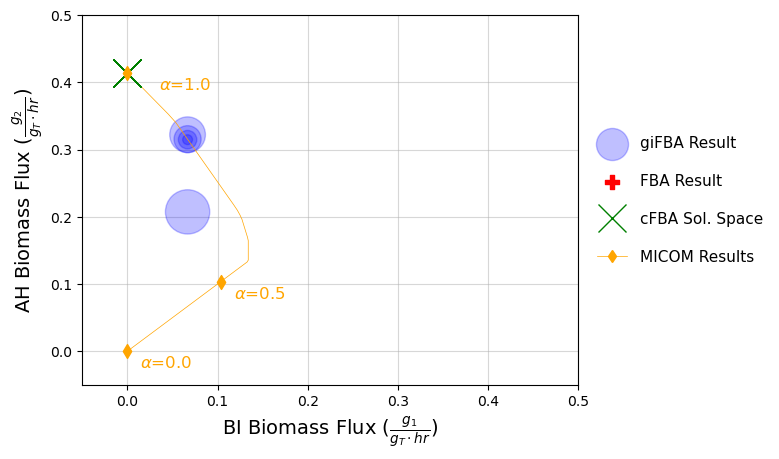

In [7]:
#plot model results

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange", "purple"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_biomass(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_biomass(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)

# compared to cobrapy FBA
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
plt.plot(cfba_results["First_Org_Flux"], cfba_results["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x",
            ms=cfba_marker_size,
            lw=0,
            label='cFBA Sol. Space',
            zorder=3)

# import plotting helper module
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import plotting_module as pm
        
# compared to MICOM (both interpretations)
pm.plot_micom_tradeoff_pts(micom_results, 
                           "relative", 
                           [0.0, 0.5, 1.0], # alpha tradeoffs to add text labels to
                           community.rel_abund, 
                           colors[3], 
                           micom_marker_size, 
                           micom_line_width, 
                           # old: [(0, 0), (-0, 0), (0, 0)]
                           [(0.014, -0.025), (0.014, -0.025), (0.035, -0.025)]) # x, y offsets for text labels

# create custom legend entry
micom_rel_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results (Rel. Rates)')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_rel_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='center right', bbox_to_anchor=(1.4, 0.5), ncol=1, frameon=False, labelspacing=1.5) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0, alpha=0.5)
plt.xlabel(r"BI Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"AH Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-0.05, 0.5)
plt.ylim(-0.05, 0.5)

plt.savefig("../figures/real_model_figs/paper_figs/2_ahallii_binfantis.svg", bbox_inches='tight')